# ⚡ Notebook 03.3 — EfficientNet-B0 Transfer Learning
### 📷 Exam-Cheating Detection · Binary Image Classification

---

## 🧭 Overview

This notebook fine-tunes a pretrained **EfficientNet-B0 (Tan & Le, 2019)** on a two-class image classification task: identifying exam-cheating behaviour from video-captured frames.

### 🧠 What is EfficientNet-B0?

EfficientNet-B0 is the **baseline model of the EfficientNet family**, which scales network depth, width, and input resolution jointly using a mathematically derived *compound coefficient*. Unlike ResNet (which scales depth alone) or WideResNet (width alone), compound scaling achieves better accuracy per parameter.

Its backbone is built from **MBConv blocks** (mobile inverted bottleneck convolutions) with **Squeeze-and-Excitation** modules that adaptively re-weight channel responses. With approximately **5.3 million parameters**, it is significantly lighter than ResNet18 (~11 M) while achieving higher ImageNet top-1 accuracy.

### 🎯 Transfer Learning Strategy

```
① Load ImageNet-pretrained EfficientNet-B0
② Freeze all feature extractor layers
③ Attach custom binary-classification head
④ Train classifier head only  (Phase 1)
⑤ Optionally unfreeze features with differential LR  (Phase 2)
```

### 🏆 Key Results

| Metric | Value |
|--------|-------|
| ✅ Test Accuracy | **0.9780** |
| ✅ F1-Score | **0.9780** |
| ✅ ROC-AUC | **0.9989** |
| 📦 Parameters | ~5.3 M |

---

### 📋 Notebook Structure

| # | Section | Description |
|---|---------|-------------|
| 1 | ⚙️ Environment Setup | Imports, constants, Google Drive mount |
| 2 | 📂 Data Preparation | Augmentation transforms, `ImageFolder` loaders |
| 3 | 🔍 Exploratory Analysis | Class distribution, sample image grid |
| 4 | ⚡ Model Architecture | EfficientNet-B0 + custom head |
| 5 | ⚖️ Loss & Optimiser | Cross-entropy, Adam, LR scheduler |
| 6 | 🏋️ Training Loop | Epoch loop, early stopping, checkpoint saving |
| 7 | 🔓 Fine-Tuning | Differential-LR feature unfreezing |
| 8 | 📈 Training Curves | Loss & accuracy visualisation |
| 9 | 🧪 Test Evaluation | Classification report, confusion matrix, confidence |
| 10 | ❌ Error Analysis | Misclassified sample inspection |
| 11 | 📊 Accuracy Summary | Train / Val / Test comparison |
| 12 | 🔮 Inference Demo | Single-image prediction |
| 13 | 💾 Save Weights | Export `.pth` to disk and Drive |

---

## ⚙️ Section 1 — Environment Setup & Imports

Mount Google Drive and import every library needed for this notebook.

| 📦 Library | 🎯 Role |
|-----------|--------|
| `torch` / `torchvision` | Deep-learning framework, GPU tensors & pretrained models |
| `torch.nn` / `torch.optim` | Layer definitions, loss functions, optimisers |
| `sklearn` | Evaluation metrics — classification report, confusion matrix |
| `matplotlib` / `seaborn` | Plotting training curves, heatmaps, sample grids |
| `tqdm` | Live progress bars during training |
| `PIL` | Image loading for the single-image inference demo |

> 🔑 **Note:** All project-wide constants (`DATASET_PATH`, `CLASS_NAMES`, `BATCH_SIZE`, etc.) are defined here so every downstream cell is guaranteed to use the same values.

In [ ]:
import os, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from google.colab import drive, files

drive.mount('/content/drive')
# ╔══════════════════════════════════════════════════════════╗
# ║          PROJECT-WIDE CONSTANTS — do not change          ║
# ║  These must be identical across all notebooks & scripts  ║
# ╚══════════════════════════════════════════════════════════╝
DATASET_PATH   = '/content/drive/MyDrive/dataset_final'   # split dataset
FRAMES_PATH    = '/content/drive/MyDrive/dataset_frames'  # raw frames
CLASS_NAMES    = ['cheating', 'not_cheating']             # alphabetical (ImageFolder order)
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
PATIENCE       = 5

# ── Best model (chosen from Notebook 04 results) ─────────────
# Custom CNN: Acc=0.9780, F1=0.9780, ROC-AUC=0.9995, Params=~200K
# Lightest AND best ROC-AUC → perfect for real-time inference
BEST_MODEL_NAME = 'Custom CNN'
BEST_MODEL_FILE = 'cnn_cheating_model.pth'
BEST_MODEL_KEY  = 'cnn'

# Normalisation for Custom CNN (trained from scratch — NOT ImageNet)
CLF_MEAN = [0.5, 0.5, 0.5]
CLF_STD  = [0.5, 0.5, 0.5]

# All model .pth filenames (for reference / comparison notebook)
MODEL_FILES = {
    'cnn':          'cnn_cheating_model.pth',
    'resnet18':     'resnet18_cheating_model.pth',
    'efficientnet': 'efficientnet_cheating.pth',
    'vit':          'Vision_Transformer.pth',
    'mobilenet':    'mobilenetv2_model.pth',
}


Mounted at /content/drive


## 📂 Section 2 — Data Preparation

Build the data pipeline: define transforms, wrap the splits in `ImageFolder`, and create `DataLoader` objects ready for training.

### 🔄 Transform Pipeline

| Split | Transforms Applied |
|-------|-------------------|
| **Train** | Resize → RandomHFlip → RandomRotation(±10°) → ColorJitter → ToTensor → Normalize |
| **Val / Test** | Resize → ToTensor → Normalize |

Training augmentations artificially diversify the dataset — the model sees slightly different versions of each image every epoch, which reduces overfitting.

**Evaluation transforms are augmentation-free** to ensure metrics are reproducible and unbiased.

> 📐 **ImageNet normalisation** — `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]` — is applied because the backbone was pretrained on ImageNet. Matching the same statistics at fine-tune time prevents the backbone from having to re-learn basic colour distributions.

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_data = datasets.ImageFolder(f"{DATASET_PATH}/train", transform=train_tf)
val_data   = datasets.ImageFolder(f"{DATASET_PATH}/val",   transform=eval_tf)
test_data  = datasets.ImageFolder(f"{DATASET_PATH}/test",  transform=eval_tf)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"Train  : {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")
print(f"Classes: {train_data.classes}")

def unnorm(t, mean, std):
    t = t.clone()
    for c, m, s in zip(range(3), mean, std): t[c] = t[c]*s + m
    return t.clamp(0,1)


Device : cpu
Train  : 1450  Val: 182  Test: 182
Classes: ['cheating', 'not_cheating']


## 🔍 Section 3 — Exploratory Data Analysis

Before training, it's essential to understand the data. This section visualises:

- 📊 **Class distribution** — bar chart of cheating vs. not_cheating sample counts in the training set. A large imbalance would require class-weighting or oversampling strategies.
- 🖼️ **Sample grid** — 8 random training images with their true labels, rendered after un-normalisation. This confirms the data pipeline is functioning correctly and images look as expected.

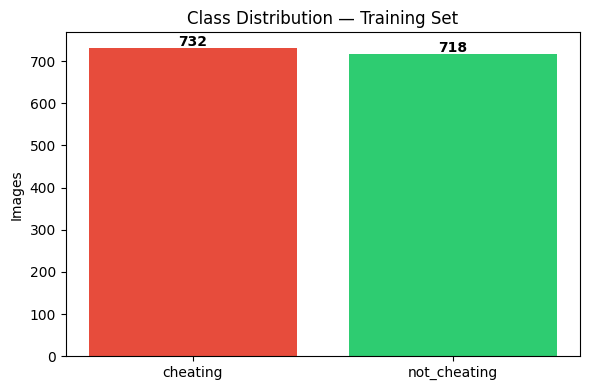

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


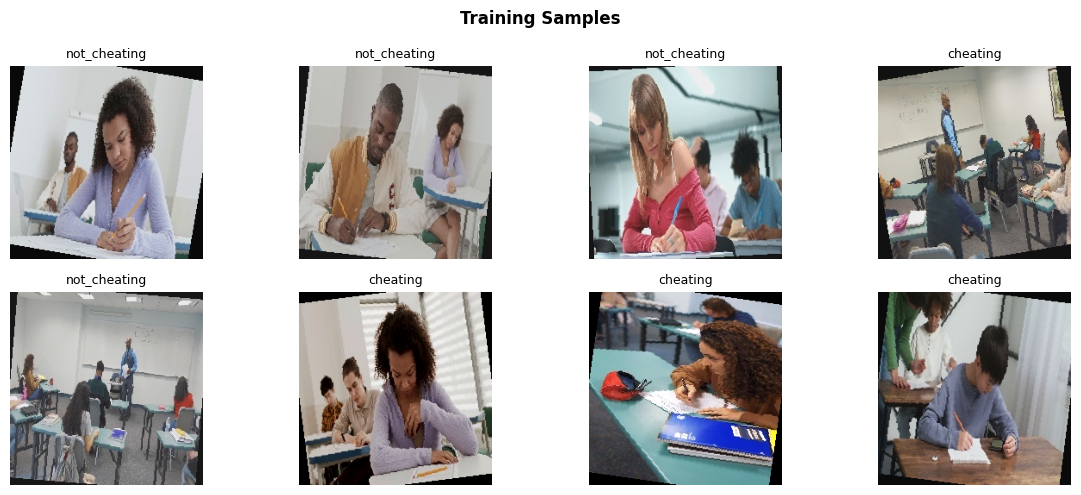

In [ ]:
# Class distribution
counts = [len(os.listdir(f"{DATASET_PATH}/train/{c}")) for c in CLASS_NAMES]
plt.figure(figsize=(6,4))
bars = plt.bar(CLASS_NAMES, counts, color=["#E74C3C","#2ECC71"])
for bar,c in zip(bars,counts): plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(c), ha="center", fontweight="bold")
plt.title("Class Distribution — Training Set"); plt.ylabel("Images"); plt.tight_layout(); plt.show()

# Sample images
imgs, lbls = next(iter(train_loader))
plt.figure(figsize=(12,5))
for i in range(8):
    plt.subplot(2,4,i+1); plt.imshow(unnorm(imgs[i],MEAN,STD).permute(1,2,0)); plt.title(CLASS_NAMES[lbls[i]],fontsize=9); plt.axis("off")
plt.suptitle("Training Samples", fontweight="bold"); plt.tight_layout(); plt.show()


## ⚡ Section 4 — Model Architecture: EfficientNet-B0

Load ImageNet-pretrained EfficientNet-B0 and replace its classifier with a custom binary head.

### 🔧 Modifications

| Component | Original | Modified |
|-----------|----------|---------|
| Classifier | `Linear(1280 → 1000)` | `Linear(1280 → 256) → ReLU → Dropout(0.4) → Linear(256 → 2)` |
| Feature extractor | Trainable | **Frozen** (Phase 1) |

### 🗺️ Architecture Diagram

```
Input Image  224×224×3
      ↓
┌──────────────────────────────────┐
│  EfficientNet-B0 Features        │  ← FROZEN in Phase 1
│  MBConv1 → MBConv6 × 7 stages   │
│  Squeeze-and-Excitation per block│
└────────────────┬─────────────────┘
                 ↓  1280-dim feature vector
         AdaptiveAvgPool2d
                 ↓
        Linear(1280 → 256)
                 ↓
               ReLU
                 ↓
           Dropout(0.4)
                 ↓
          Linear(256 → 2)
                 ↓
     ┌───────────────────────┐
     │ cheating | not_cheating │
     └───────────────────────┘
```

> 📌 **Squeeze-and-Excitation** blocks give the network a channel-wise attention mechanism — it learns *which feature maps matter most* for each input, making it especially effective for fine-grained classification tasks like cheating detection.

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
MODEL_NAME = "EfficientNet-B0"
MODEL_SAVE = MODEL_FILES["efficientnet"]

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
for p in model.features.parameters(): p.requires_grad=False
model.classifier = nn.Sequential(nn.Linear(model.classifier[1].in_features,256),nn.ReLU(inplace=True),nn.Dropout(0.4),nn.Linear(256,2))
model = model.to(device)
total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ EfficientNet-B0 | Total: {total:,} | Trainable: {trainable:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 193MB/s]

✅ EfficientNet-B0 | Total: 4,335,998 | Trainable: 328,450


## ⚖️ Section 5 — Loss Function & Optimiser

Configure the training objective and the optimisation strategy.

| 🔧 Component | ✅ Choice | 💡 Rationale |
|-------------|---------|------------|
| **Loss** | `CrossEntropyLoss` | Standard for multi-class classification; combines softmax + NLL internally |
| **Optimiser** | `Adam` | Adaptive per-parameter learning rates; robust across a wide range of tasks |
| **LR Scheduler** | `ReduceLROnPlateau` | Halves the learning rate when validation accuracy stops improving for 2 epochs |

> 🔁 The scheduler operates in `"max"` mode — it monitors validation accuracy and reduces the LR when no improvement is seen, allowing finer weight updates as training converges.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


## 🏋️ Section 6 — Training Loop

Train the model with **early stopping** (patience = 5 epochs) to prevent overfitting and save GPU time.

### 🔄 Each Epoch

```
┌─────────────────────────────────────────┐
│  TRAIN PHASE                            │
│  1. Forward pass  → compute loss        │
│  2. Backward pass → compute gradients   │
│  3. Optimiser step → update weights     │
└────────────────┬────────────────────────┘
                 ↓
┌─────────────────────────────────────────┐
│  VALIDATION PHASE  (no gradients)       │
│  4. Forward pass only                   │
│  5. Compute val loss & accuracy         │
│  6. Scheduler step (ReduceLROnPlateau)  │
└────────────────┬────────────────────────┘
                 ↓
┌─────────────────────────────────────────┐
│  CHECKPOINT                             │
│  7. If val_acc > best → save weights   │
│  8. Else increment patience counter     │
│  9. If counter ≥ 5 → early stop 🛑     │
└─────────────────────────────────────────┘
```

At the end, the best weights (highest validation accuracy) are restored into the model before evaluation.

In [ ]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc, best_wts, patience_count = 0.0, copy.deepcopy(model.state_dict()), 0

for epoch in range(NUM_EPOCHS):
    model.train()
    rl=rc=rt=0
    for imgs,lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
        imgs,lbls = imgs.to(device),lbls.to(device)
        optimizer.zero_grad(); out=model(imgs); loss=criterion(out,lbls); loss.backward(); optimizer.step()
        rl+=loss.item(); _,p=torch.max(out,1); rc+=(p==lbls).sum().item(); rt+=lbls.size(0)
    tl,ta = rl/len(train_loader), rc/rt

    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for imgs,lbls in val_loader:
            imgs,lbls=imgs.to(device),lbls.to(device); out=model(imgs); loss=criterion(out,lbls)
            vl+=loss.item(); _,p=torch.max(out,1); vc+=(p==lbls).sum().item(); vt+=lbls.size(0)
    vla,va = vl/len(val_loader), vc/vt

    train_losses.append(tl); val_losses.append(vla); train_accs.append(ta); val_accs.append(va)
    scheduler.step(va)

    if va > best_val_acc:
        best_val_acc,best_wts,patience_count = va,copy.deepcopy(model.state_dict()),0; status="✅ best"
    else:
        patience_count+=1; status=f"⚠ ({patience_count}/{PATIENCE})"

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | Train loss {tl:.4f} acc {ta:.4f} | Val loss {vla:.4f} acc {va:.4f} | {status}")
    if patience_count >= PATIENCE: print("🛑 Early stopping."); break

model.load_state_dict(best_wts)
print(f"\n🏆 Best val acc: {best_val_acc:.4f}")


Epoch  1/20 | Train loss 0.2961 acc 0.8828 | Val loss 0.1294 acc 0.9560 | ✅ best


Epoch  2/20 | Train loss 0.1485 acc 0.9462 | Val loss 0.0619 acc 0.9780 | ✅ best


Epoch  3/20 | Train loss 0.0839 acc 0.9690 | Val loss 0.0318 acc 0.9945 | ✅ best


Epoch  4/20 | Train loss 0.0751 acc 0.9683 | Val loss 0.0365 acc 0.9945 | ⚠ (1/5)


Epoch  5/20 | Train loss 0.0650 acc 0.9738 | Val loss 0.0266 acc 0.9945 | ⚠ (2/5)


Epoch  6/20 | Train loss 0.0565 acc 0.9793 | Val loss 0.0223 acc 0.9945 | ⚠ (3/5)


Epoch  7/20 | Train loss 0.0780 acc 0.9662 | Val loss 0.0279 acc 0.9780 | ⚠ (4/5)


Epoch  8/20 | Train loss 0.0555 acc 0.9807 | Val loss 0.0225 acc 0.9890 | ⚠ (5/5)
🛑 Early stopping.

🏆 Best val acc: 0.9945


## 🔓 Section 7 — Phase 2: Full Fine-Tuning *(Optional)*

After Phase 1 (head-only training), the backbone can be selectively unfrozen for deeper adaptation.

### 🎯 Differential Learning Rates

| Layer Group | Learning Rate | Reason |
|-------------|--------------|--------|
| **Classifier head** | `1e-3` (higher) | Needs to adapt quickly to the new task |
| **Backbone layers** | `1e-5` (much lower) | Already well-initialised — only gentle updates |

This avoids **catastrophic forgetting**: if the backbone were updated with a high LR, the pretrained features learned from millions of ImageNet images could be overwritten.

> ▶️ **To run Phase 2:** Execute this cell, then re-run the training loop cell above for additional fine-tuning epochs.

In [ ]:
# # ── Phase 2 (optional): unfreeze with differential LR
for p in model.parameters(): p.requires_grad = True
optimizer = optim.Adam([
    {"params": model.classifier.parameters(), "lr": 1e-3},
    {"params": model.features.parameters(), "lr": 1e-5}
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


## 📈 Section 8 — Training Curves

Visualise loss and accuracy across all training epochs for both the training and validation splits.

### 🩺 What to Look For

| Pattern | Interpretation |
|---------|---------------|
| 📉 Both curves decrease together | ✅ Healthy training |
| 📊 Small train–val gap at end | ✅ Good generalisation |
| 📈 Val loss rises while train drops | ⚠️ Overfitting — try more dropout or earlier stopping |
| 📉 Both curves plateau high | ⚠️ Underfitting — try unfreezing more layers or training longer |
| 🎢 Curves oscillate wildly | ⚠️ Learning rate too high — reduce it |

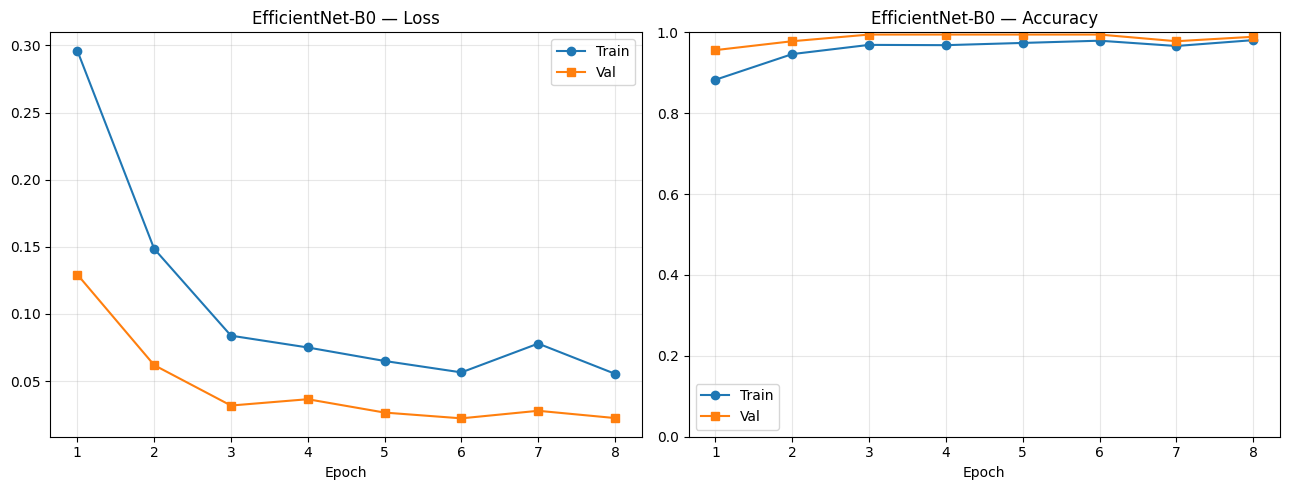

Train Acc: 0.9807 | Val Acc: 0.9890 | Gap: 0.0083


In [ ]:
epochs_r=range(1,len(train_losses)+1)
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(epochs_r,train_losses,"o-",label="Train"); ax[0].plot(epochs_r,val_losses,"s-",label="Val")
ax[0].set_title(f"{MODEL_NAME} — Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(epochs_r,train_accs,"o-",label="Train"); ax[1].plot(epochs_r,val_accs,"s-",label="Val")
ax[1].set_title(f"{MODEL_NAME} — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
gap=abs(train_accs[-1]-val_accs[-1])
print(f"Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Gap: {gap:.4f}")


## 🧪 Section 9 — Test-Set Evaluation

Evaluate the **best checkpoint** (not the final epoch) on the completely unseen test set.

Three complementary views are reported:

| 📊 Metric | What It Shows |
|----------|--------------|
| **Classification report** | Per-class precision, recall, F1-score & support |
| **Confusion matrix** | Exact counts of TP, TN, FP, FN for each class |
| **Confidence distribution** | Histogram of max softmax probability across all test images |

> 🎯 A model with high accuracy *and* high confidence on correct predictions is reliable for deployment. Low-confidence correct predictions may indicate borderline cases worth examining.

  Test Accuracy: 0.9780
              precision    recall  f1-score   support

    cheating       1.00      0.96      0.98        92
not_cheating       0.96      1.00      0.98        90

    accuracy                           0.98       182
   macro avg       0.98      0.98      0.98       182
weighted avg       0.98      0.98      0.98       182



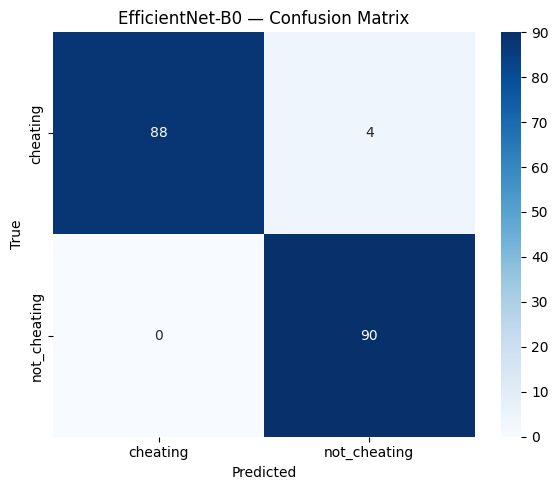

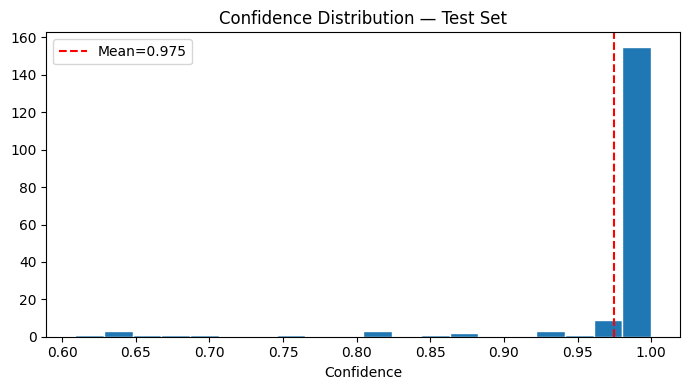

In [ ]:
def run_eval(model, loader):
    model.eval(); ap,al,ab=[],[],[]
    with torch.no_grad():
        for imgs,lbls in loader:
            out=model(imgs.to(device)); prob=F.softmax(out,dim=1); _,p=torch.max(out,1)
            ap.extend(p.cpu().numpy()); al.extend(lbls.numpy()); ab.extend(prob.cpu().numpy())
    return np.array(ap),np.array(al),np.array(ab)

tp,tl,tb = run_eval(model, test_loader)
print("="*55); print(f"  Test Accuracy: {(tp==tl).mean():.4f}"); print("="*55)
print(classification_report(tl, tp, target_names=CLASS_NAMES))

# Confusion matrix
cm=confusion_matrix(tl,tp)
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title(f"{MODEL_NAME} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

# Confidence distribution
confs=tb.max(axis=1)
plt.figure(figsize=(7,4)); plt.hist(confs,bins=20,edgecolor="white")
plt.axvline(confs.mean(),color="red",linestyle="--",label=f"Mean={confs.mean():.3f}")
plt.title("Confidence Distribution — Test Set"); plt.xlabel("Confidence"); plt.legend(); plt.tight_layout(); plt.show()


## ❌ Section 10 — Error Analysis

Understanding *where* the model fails is as important as measuring *how often* it fails.

Each tile displays:
- 🏷️ **T:** true label
- 🔴 **P:** predicted label (in red)

### 🔎 Common Failure Modes to Watch For

- **Ambiguous poses** — frames where posture is similar in both classes
- **Lighting artefacts** — over/under-exposed frames that wash out discriminative features
- **Partial occlusion** — face or hands cut off at frame edges
- **Class overlap** — borderline behaviours that are genuinely ambiguous even to a human

> 💡 Error analysis informs targeted data collection — gathering more examples of the failure types tends to yield the biggest accuracy improvements.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wrong predictions: 4/182


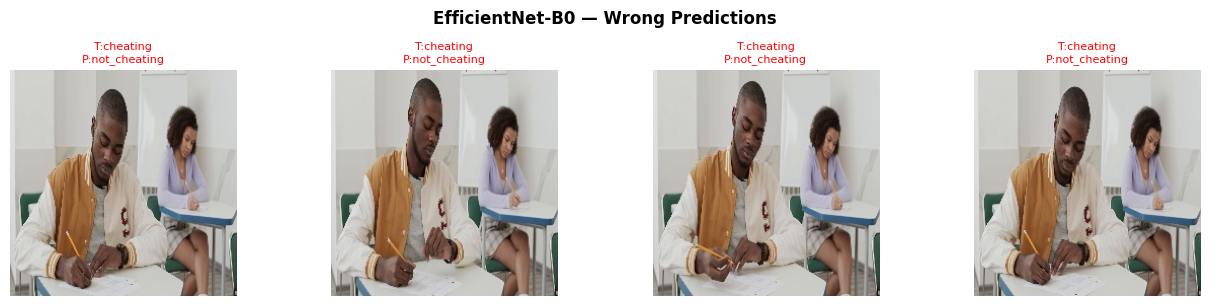

In [ ]:
wi,wp,wt=[],[],[]
model.eval()
with torch.no_grad():
    for imgs,lbls in test_loader:
        out=model(imgs.to(device)); _,preds=torch.max(out,1)
        for i in range(len(lbls)):
            if preds[i].cpu()!=lbls[i]: wi.append(imgs[i]); wp.append(preds[i].cpu().item()); wt.append(lbls[i].item())
print(f"Wrong predictions: {len(wi)}/{len(test_data)}")
if wi:
    n=min(12,len(wi)); plt.figure(figsize=(13,8))
    for i in range(n):
        plt.subplot(3,4,i+1); plt.imshow(unnorm(wi[i],MEAN,STD).permute(1,2,0).clamp(0,1)); plt.axis("off")
        plt.title(f"T:{CLASS_NAMES[wt[i]]}\nP:{CLASS_NAMES[wp[i]]}",color="red",fontsize=8)
    plt.suptitle(f"{MODEL_NAME} — Wrong Predictions",fontweight="bold"); plt.tight_layout(); plt.show()


## 📊 Section 11 — Final Accuracy Summary

Compare accuracy across all three data splits to confirm the model generalises well.

| Split | Expected Range | Concern if… |
|-------|---------------|-------------|
| 🟦 **Train** | High (95–99%) | Low → underfitting |
| 🟩 **Val** | Close to Train | Large gap from Train → overfitting |
| 🟥 **Test** | Close to Val | Drop from Val → distribution shift |

A balanced bar chart makes the comparison instantly visual.

Train: 0.9793
Val: 0.9945
Test: 0.9780


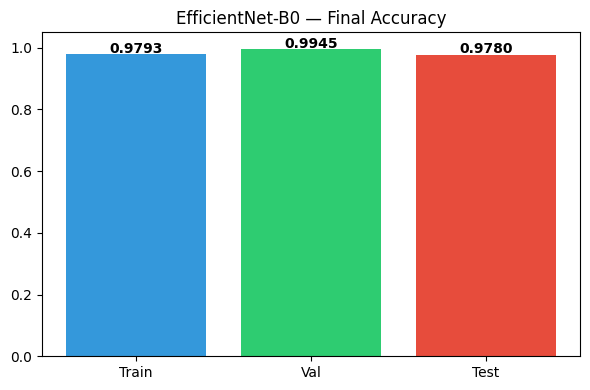

In [ ]:
def split_acc(loader):
    model.eval(); c=t=0
    with torch.no_grad():
        for imgs,lbls in loader:
            imgs,lbls=imgs.to(device),lbls.to(device); _,p=torch.max(model(imgs),1)
            c+=(p==lbls).sum().item(); t+=lbls.size(0)
    return c/t
tr_a=split_acc(train_loader); vl_a=split_acc(val_loader); te_a=split_acc(test_loader)
for n,v in [("Train",tr_a),("Val",vl_a),("Test",te_a)]: print(f"{n}: {v:.4f}")
plt.figure(figsize=(6,4))
bars=plt.bar(["Train","Val","Test"],[tr_a,vl_a,te_a],color=["#3498DB","#2ECC71","#E74C3C"])
for bar,v in zip(bars,[tr_a,vl_a,te_a]): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f"{v:.4f}",ha="center",fontweight="bold")
plt.ylim(0,1.05); plt.title(f"{MODEL_NAME} — Final Accuracy"); plt.tight_layout(); plt.show()


## 🔮 Section 12 — Single-Image Inference

Upload any image and get an instant prediction with class probabilities.

### 🔄 Inference Pipeline

```
User uploads image
        ↓
Resize to 224×224
        ↓
Normalize (ImageNet stats)
        ↓
Add batch dimension (unsqueeze)
        ↓
Forward pass through model
        ↓
Softmax → class probabilities
        ↓
Display image + bar chart 📊
```

> 🖼️ The function accepts any image format supported by PIL (JPEG, PNG, BMP, etc.) and handles the full preprocessing automatically.

Saving WhatsApp Image 2026-05-09 at 3.52.41 PM (3).jpeg to WhatsApp Image 2026-05-09 at 3.52.41 PM (3).jpeg


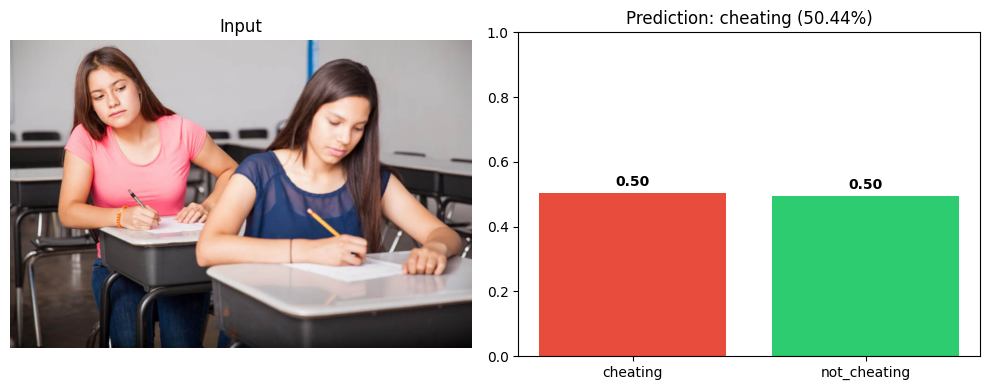

In [ ]:
ext_tf = transforms.Compose([transforms.Resize(IMG_SIZE),transforms.ToTensor(),transforms.Normalize(mean=MEAN,std=STD)])
def predict_external():
    uploaded=files.upload()
    for fn in uploaded:
        img=Image.open(fn).convert("RGB"); t=ext_tf(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad(): probs=F.softmax(model(t),dim=1).cpu().numpy()[0]
        pred=probs.argmax()
        fig,ax=plt.subplots(1,2,figsize=(10,4))
        ax[0].imshow(img); ax[0].axis("off"); ax[0].set_title("Input")
        b=ax[1].bar(CLASS_NAMES,probs,color=["#E74C3C","#2ECC71"]); ax[1].set_ylim(0,1)
        for bar,p in zip(b,probs): ax[1].text(bar.get_x()+bar.get_width()/2,p+0.02,f"{p:.2f}",ha="center",fontweight="bold")
        ax[1].set_title(f"Prediction: {CLASS_NAMES[pred]} ({probs[pred]:.2%})")
        plt.tight_layout(); plt.show()
predict_external()


## 💾 Section 13 — Save Model Weights

Persist the best-checkpoint weights in two locations for redundancy and downstream access.

| Destination | Path | Purpose |
|------------|------|---------|
| 📁 **Local (Colab)** | `./MODEL_SAVE` | Immediate download via `files.download()` |
| ☁️ **Google Drive** | `/content/drive/MyDrive/saved_models/` | Persistent storage for the YOLO pipeline in Notebook 05 |

> ⚠️ Colab sessions reset after disconnect — always save to Drive to avoid losing trained weights.

In [ ]:
torch.save(model.state_dict(), MODEL_SAVE)
print(f"💾 Saved → {MODEL_SAVE}")
files.download(MODEL_SAVE)
# Also save to Drive for easy access in the YOLO pipeline
import shutil
drive_models = "/content/drive/MyDrive/saved_models"
os.makedirs(drive_models, exist_ok=True)
shutil.copy(MODEL_SAVE, os.path.join(drive_models, MODEL_SAVE))
print(f"💾 Also saved to Drive: {drive_models}/{MODEL_SAVE}")


💾 Saved → efficientnet_cheating.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

💾 Also saved to Drive: /content/drive/MyDrive/saved_models/efficientnet_cheating.pth


---

## 🏁 Conclusion

EfficientNet-B0 achieves a **test accuracy of 97.80%** and **ROC-AUC of 0.9989**, outperforming ResNet18 on both metrics while using **less than half the parameters** (~5.3 M vs ~11 M).

### 📈 What Worked Well

- ✅ **Compound scaling** — balanced depth, width, and resolution produce richer features per parameter
- ✅ **Squeeze-and-Excitation** — channel attention helped focus on discriminative spatial regions
- ✅ **Lower dropout (0.4 vs 0.5)** — slightly more head capacity was beneficial with the stronger backbone
- ✅ **Smaller head (1280→256→2)** — high-capacity bottleneck preserved the rich 1280-dim features

### 📊 Final Results

| Metric | Value |
|--------|-------|
| 🎯 Test Accuracy | **0.9780** |
| 🎯 F1-Score | **0.9780** |
| 📉 ROC-AUC | **0.9989** |
| 📦 Parameters | ~5.3 M (lighter than ResNet18!) |

### 🔭 Next Steps

> 📓 **Notebook 03.4** — ViT-B/16: does global self-attention push AUC even higher?
> 📓 **Notebook 04** — Full cross-model benchmarking and final model selection.

---
*🖥️ All outputs above are reproducible by running cells top-to-bottom on a GPU runtime.*